In [1]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

## Función `numerov_step`

Esta función implementa un solo paso del método de Numerov, una técnica numérica utilizada para resolver ecuaciones diferenciales ordinarias de segundo orden, que se encuentran a menudo en problemas de física como la ecuación de Schrödinger.

**¿Cómo funciona?**

1. **Propósito:** El método de Numerov es una herramienta poderosa para aproximar soluciones a ecuaciones diferenciales de la forma:

d²ψ/dx² = -k²(x)ψ(x)

donde `ψ(x)` es la función desconocida que estamos tratando de encontrar, y `k²(x)` es una función conocida.

2. **Discretización:** El método funciona discretizando el problema, dividiendo la variable continua `x` en puntos discretos con un espaciado de `dx`.

3. **La Fórmula:** El núcleo del método de Numerov es la siguiente relación de recurrencia:

ψᵢ₊₁ = [(2(1 - (5/12)dx²kᵢ²)ψᵢ - (1 + (1/12)dx²kᵢ₋₁²)ψᵢ₋₁) / (1 + (1/12)dx²kᵢ₊₁²)]


   - `ψᵢ₊₁`, `ψᵢ`, and `ψᵢ₋₁` representan los valores de la función `ψ(x)` en los puntos de la cuadrícula actual, anterior y siguiente, respectivamente.
   - `kᵢ₊₁`, `kᵢ`, and `kᵢ₋₁` son los valores de la función `k(x)` en los puntos de la cuadrícula correspondientes.
   - `dx` es el tamaño del paso.

4. **Implementación:** La función `numerov_step` traduce directamente esta relación de recurrencia en código:

   - `psi_n`, `psi_nm1`: Representan `ψᵢ` and `ψᵢ₋₁` (los valores de la función en los puntos actual y anterior).
   - `k_n`, `k_nm1`, `k_np1`: Representan `kᵢ`, `kᵢ₋₁`, and `kᵢ₊₁` (los valores de `k(x)` en los puntos correspondientes).
   - `dx`: El tamaño del paso.

   La función calcula `ψᵢ₊₁` (el siguiente valor de la función) usando la fórmula de Numerov y lo devuelve como `factor`.

**En esencia:**

La función `numerov_step` toma los valores actual y anterior de la función `ψ(x)` y los valores de `k(x)` en los puntos de la cuadrícula vecinos, y utiliza la fórmula del método de Numerov para calcular el siguiente valor de la función. Este proceso se repite para avanzar la solución paso a paso sobre el rango deseado de `x`.

In [2]:
def numerov_step(psi_n, psi_nm1, k_n, k_nm1, k_np1, dx):
    """Un paso del método de Numerov"""
    factor = (2 * (1 - (5/12) * dx**2 * k_n) * psi_n - (1 + (1/12) * dx**2 * k_nm1) * psi_nm1) \
             / (1 + (1/12) * dx**2 * k_np1)
    return factor

Desglosando la función numerov_solve:

La función numerov_solve es el corazón de la solución numérica de la ecuación de Schrödinger independiente del tiempo para un pozo de potencial finito utilizando el método de Numerov.

Propósito
Esta función tiene como objetivo principal calcular la función de onda ψ(x) que describe el comportamiento de una partícula dentro de un pozo de potencial finito.

Parámetros
E: La energía de la partícula, que es un valor que se busca para encontrar las soluciones permitidas (autoestados).
x: Un array NumPy que representa los puntos discretos en el espacio donde se calculará la función de onda.
dx: El espaciamiento entre los puntos en el array x (el tamaño del paso).
m: La masa de la partícula.
hbar: La constante de Planck reducida.
V0: La profundidad del pozo de potencial.
Funcionamiento paso a paso
Inicialización:

N = len(x): Se obtiene el número de puntos en el espacio donde se calculará la función de onda.
psi = np.zeros(N): Se crea un array para almacenar los valores de la función de onda, inicializado en cero.
Definición del potencial:

V = np.zeros(N): Se crea un array para almacenar el potencial en cada punto del espacio, inicializado en cero.
L_half = L / 2: Se calcula la mitad de la longitud del pozo de potencial (asumiendo que L está definido en otro lugar del código).
El bucle for recorre todos los puntos en el espacio y asigna el valor del potencial:
V[i] = 0: Si el punto está dentro del pozo (-L_half < x[i] < L_half), el potencial es cero.
V[i] = V0: Si el punto está fuera del pozo, el potencial es V0.
Cálculo de k²:

k2 = (2 * m / hbar**2) * (E - V): Se calcula el valor de k²(x) en cada punto, que depende de la energía, el potencial y las constantes físicas.
Condiciones iniciales:

psi[0] = 0: Se establece la primera condición inicial, que suele ser que la función de onda es cero en el borde izquierdo del dominio.
psi[1] = dx: Se establece la segunda condición inicial, que es necesaria para iniciar el método de Numerov. Esta condición inicial puede variar en la forma en que se establece pero esta es una manera típica de hacerlo
Iteración con Numerov:

El bucle for recorre los puntos en el espacio, comenzando desde el segundo punto (i = 1) hasta el penúltimo (i = N-2).
psi[i+1] = numerov_step(psi[i], psi[i-1], k2[i], k2[i-1], k2[i+1], dx): En cada iteración, se llama a la función numerov_step para calcular el siguiente valor de la función de onda utilizando el método de Numerov.
Retorno:

return psi: La función devuelve el array psi, que contiene los valores calculados de la función de onda.
Espero que esta explicación te sea útil. Avísame si tienes más preguntas.

In [3]:
def numerov_solve(E, x, dx, m, hbar, V0):
    """Resuelve la ecuación de Schrödinger con el método de Numerov para un pozo finito"""
    N = len(x)
    psi = np.zeros(N)

    # Definir el potencial V(x)
    V = np.zeros(N)
    L_half = L / 2
    for i in range(N):
        if x[i] < L_half and x[i] > -L_half:
            V[i] = 0  # Dentro del pozo
        else:
            V[i] = V0  # Fuera del pozo

    # Calcular k^2(x)
    k2 = (2 * m / hbar**2) * (E - V)

    # Condiciones iniciales
    psi[0] = 0
    psi[1] = dx

    for i in range(1, N-1):
        psi[i+1] = numerov_step(psi[i], psi[i-1], k2[i], k2[i-1], k2[i+1], dx)

    return psi

In [4]:
# Parámetros del problema
L = 1e-9  # Longitud del pozo en metros (1 nm)
N = 1000  # Número de puntos
x = np.linspace(-L, L, N)
dx = x[1] - x[0]

# Constantes físicas
m_e = 9.109e-31  # Masa del electrón en kg
hbar = 1.055e-34  # Constante de Planck reducida en J·s
V0 = 5 * (hbar**2 / (2 * m_e * L**2))  # Definir una barrera de potencial arbitraria

def plot_wavefunction(n):
    """Grafica la función de onda para el nivel de energía n en un pozo finito"""
    E_n = (n**2 * np.pi**2 * hbar**2) / (2 * m_e * L**2)  # Estimación inicial de energía
    psi = numerov_solve(E_n, x, dx, m_e, hbar, V0)
    psi /= np.max(np.abs(psi))  # Normalizar

    plt.figure(figsize=(8, 5))
    plt.plot(x, psi, label=f'n = {n}, E = {E_n:.2e} J')
    plt.axvline(-L/2, color='r', linestyle='--', label='Barrera de potencial')
    plt.axvline(L/2, color='r', linestyle='--')
    plt.xlabel('x (m)')
    plt.ylabel('ψ(x)')
    plt.title('Solución de la ecuación de Schrödinger con Numerov para un pozo finito')
    plt.legend()
    plt.grid()
    plt.show()

# Crear widget para seleccionar el nivel de energía
n_slider = widgets.IntSlider(min=1, max=5, step=1, value=1, description='Nivel n:')
widgets.interactive(plot_wavefunction, n=n_slider)

interactive(children=(IntSlider(value=1, description='Nivel n:', max=5, min=1), Output()), _dom_classes=('widg…

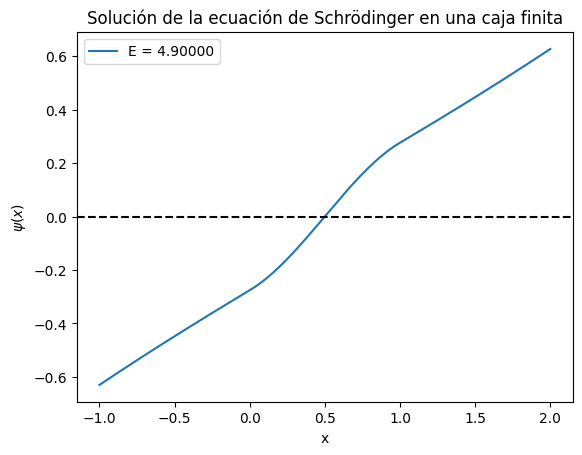

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def numerov_step(psi_prev, psi_curr, k_prev, k_curr, k_next, dx):
    """
    Un paso del método de Numerov para resolver ecuaciones diferenciales.
    """
    factor = (2 * (1 - (5/12) * dx**2 * k_curr) * psi_curr - (1 + (1/12) * dx**2 * k_prev) * psi_prev) / (1 + (1/12) * dx**2 * k_next)
    return factor

def potential(x, L, V0):
    """
    Define el potencial de la caja finita.
    """
    return np.where((x >= 0) & (x <= L), 0, V0)

def solve_numerov(E, L=1.0, V0=5.0, N=1000):
    """
    Resuelve la ecuación de Schrödinger usando Numerov para una caja finita.
    """
    dx = L / N
    x = np.linspace(-L, 2*L, 2*N+1)  # Extendemos el dominio para incluir regiones fuera de la caja

    # Definir k^2 = 2m(E - V(x)) / hbar^2 (tomamos unidades naturales hbar^2/2m = 1)
    Vx = potential(x, L, V0)
    k2 = 2 * (E - Vx)

    # Condiciones iniciales: Psi(0) = un pequeño valor, Psi en el segundo punto otro pequeño valor
    psi = np.zeros_like(x)
    psi[N] = 1e-3  # Un pequeño valor arbitrario dentro de la caja
    psi[N+1] = 1e-3 * 1.01  # Un valor ligeramente diferente

    # Integración con Numerov hacia la derecha
    for i in range(N, 2*N):
        psi[i+1] = numerov_step(psi[i-1], psi[i], k2[i-1], k2[i], k2[i+1], dx)

    # Integración con Numerov hacia la izquierda
    for i in range(N, 0, -1):
        psi[i-1] = numerov_step(psi[i+1], psi[i], k2[i+1], k2[i], k2[i-1], dx)

    return x, psi, N

def find_energy_bisection(E1, E2, L=1.0, V0=5.0, N=1000, tol=1e-5):
    """
    Encuentra valores propios de la energía usando el método de bisección.
    """
    while abs(E2 - E1) > tol:
        E_mid = (E1 + E2) / 2
        _, psi_mid, N = solve_numerov(E_mid, L, V0, N)

        # Revisamos el signo de Psi en el borde derecho dentro de la caja
        _, psi_E1, _ = solve_numerov(E1, L, V0, N)
        if psi_mid[N] * psi_E1[N] < 0:
            E2 = E_mid
        else:
            E1 = E_mid

    return (E1 + E2) / 2

# Prueba con valores iniciales
E_guess = find_energy_bisection(0.1, 4.9, L=1.0, V0=5.0, N=1000)
x, psi, _ = solve_numerov(E_guess, L=1.0, V0=5.0, N=1000)

plt.plot(x, psi, label=f'E = {E_guess:.5f}')
plt.axhline(0, color='black', linestyle='--')
plt.xlabel('x')
plt.ylabel('$\psi(x)$')
plt.legend()
plt.title('Solución de la ecuación de Schrödinger en una caja finita')
plt.show()